<a href="https://colab.research.google.com/github/dowsettl/lehua-dowsett/blob/main/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lehua Dowsett

*Intro to Neural Data Analysis*

**2/20/2026**

In [25]:
# I used the import function to import pandas, matplotlib.pyplot and scipy.stats
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [26]:
# I used pandas to simplify the expanded set of imported raw data that was in csv format
url_1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded_v2.csv'
patch_seq = pd.read_csv(url_1)

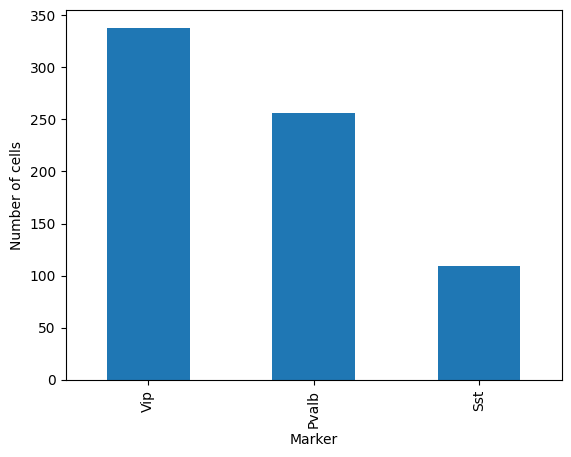

In [41]:
# I used the df.plot method from the pandas module to make a bar graph displaying the number of cells that were vip, sst, or pvalb.
patch_seq['Marker'].value_counts().plot(kind='bar')
plt.ylabel('Number of cells')
plt.xlabel('Marker')

plt.show()

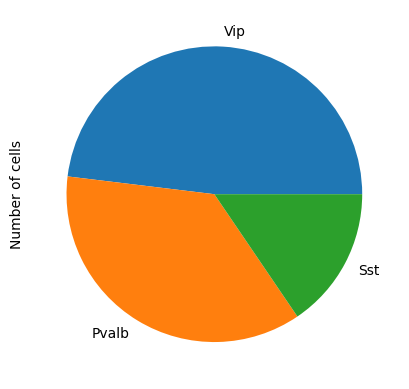

In [28]:
# I used the same method from above put to display the data in pie chart form.
patch_seq['Marker'].value_counts().plot(kind='pie')
plt.ylabel('Number of cells')

plt.show()

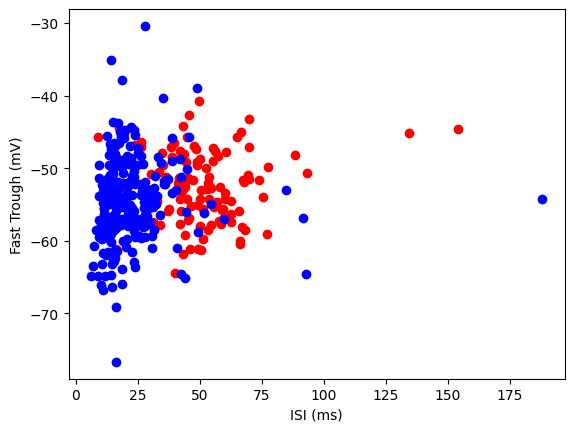

In [29]:
# I used the for loop in order to make a scatter plot that displayed the sst neurons in red and the pvlab neurons in blue with the fast trough on the y axis and the ISI on the x axis.
patch_length = len(patch_seq)

for i in range(patch_length):
  if patch_seq.iloc[i,2] == 'Sst':
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")
  if patch_seq.iloc[i,2] == 'Pvalb':
    plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

plt.ylabel("Fast Trough (mV)")
plt.xlabel("ISI (ms)")

plt.show()

In [30]:
# Using the def function, I defined the patchScatter() to execute the code from above.
def patchScatter():
    """
    Creates a scatter plot of patch_seq and displays certain dot colors
    depending on the type of Marker.
    """
    patch_length = len(patch_seq)

    for i in range(patch_length):
      if patch_seq.iloc[i,2] == 'Sst':
        plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "red")
      if patch_seq.iloc[i,2] == 'Pvalb':
        plt.scatter(patch_seq.iloc[i,0],patch_seq.iloc[i,1],color = "blue")

    plt.ylabel("Fast Trough (mV)")
    plt.xlabel("ISI (ms)")

    plt.show()

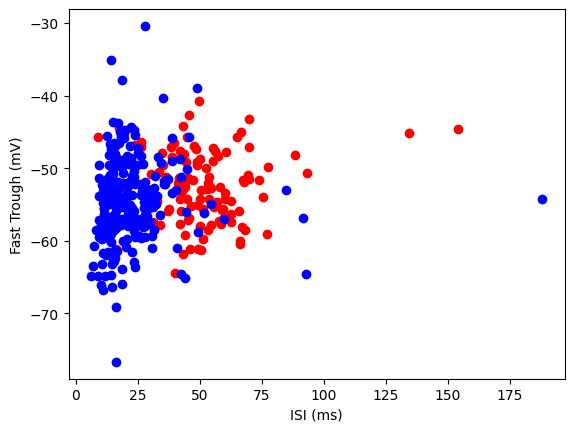

In [31]:
# I called the defined patchScatter() function
patchScatter()

In [35]:
# I used the provided method syntax to obtain the mean, SD and the range of the fast trough column for sst neurons and pvalb neurons.
patch_seq.groupby('Marker')['Fast_Trough'].describe()

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254
Vip,338.0,-45.290682,5.813754,-63.125000,-48.764066,-45.903126,-42.206251,-20.350002


The Pvalb neurons appear to have a slightly more negative undershoot mean following an action potential than the Sst neurons.

In [39]:
# Using the provided syntax, I tested the skewness of the fast trough data for the different neurons.
patch_seq.groupby('Marker')['Fast_Trough'].skew()

,Fast_Trough
Marker,
Pvalb,0.195360
Sst,0.001250
Vip,0.684606


After running the skewness test, the Fast_Trough for both the Sst and the Pvalb seem to indicate a normal distribution because the both values are between -0.5 and 0.5.

In [40]:
# Using the provided syntax, I tested the skewness of the ISI data for the different neurons.
patch_seq.groupby('Marker')['ISI'].skew()

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850
Vip,3.934749


After running the skewness test, the ISI for both the Sst and Pvalb seem to indicate a skewed distribution because both values are >0.5.

In [37]:
# Using the provided syntax, I perfromed a t-test comparing the fast trough of the sst neurons and the pvalb neurons.
sst_neurons = patch_seq[patch_seq['Marker']=='Sst']
pvalb_neurons = patch_seq[patch_seq['Marker']=='Pvalb']

stats.ttest_ind(sst_neurons['Fast_Trough'], pvalb_neurons['Fast_Trough'])

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

After performing the Fat_Trough t-test, the undershoot voltage for Sst and the undershoot voltage for Pvalb are significantly different and come from different distributions because the p-value is <0.05.

In [38]:
# I used the provided syntax to remove the missing values from the data set and create two new variables. Then I used the same syntax as above to perform a t-test comparing the ISI of the sst neurons and the pvalb neurons.
sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()

stats.ttest_ind(sst, pvalb)

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

After performing the ISI t-test, the ISI for Sst and the ISI for Pvalb re significantly different and come from different distributions because the p-value is <0.05.